In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [3]:
# with open('Studentskillgap.xlsx','r',encoding='unicode_escape') as f:
#     for i in range(5):
#         print(f.readline())
df=pd.read_excel('Studentskillgap.xlsx')
print(df)
print(df.head())
print(df.columns.to_list())


                name                     email_id        year  \
0    Shravani Khurpe  shravani.khurpe@hotmail.com    3rd Year   
1      Bhumika Yadav    bhumika.yadav@hotmail.com    3rd Year   
2     Nandana Pramod     nandana.pramod@gmail.com    3rd Year   
3       Janvi Thakur     janvi.thakur@hotmail.com    3rd Year   
4      Atharva Joshi    atharva.joshi@hotmail.com    3rd Year   
..               ...                          ...         ...   
495       Neha Reddy          nehareddy@bbc.co.uk    3rd Year   
496    Vikram Sharma     vikramsharma@dropbox.com    1st Year   
497      Rohan Patel         rohanpatel@mysql.com  Final Year   
498       Neha Patel        nehapatel@squidoo.com    1st Year   
499    Karthik Reddy  karthikreddy@purevolume.com  Final Year   

        current_course                                   technical_skills  \
0               B.Tech          Data Analysis, Python, SQL, Cybersecurity   
1               B.Tech                       Python, SQL, Cloud C

In [4]:
# data cleaning
print(df.info())
print(pd.isnull(df).sum())
# cleaning column names (remove spaces)
df.columns=df.columns.str.strip()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   name                       500 non-null    object
 1   email_id                   500 non-null    object
 2   year                       500 non-null    object
 3   current_course             500 non-null    object
 4   technical_skills           500 non-null    object
 5   programming_languages      500 non-null    object
 6   rating                     500 non-null    int64 
 7   soft_skills                500 non-null    object
 8   rating.1                   500 non-null    int64 
 9   projects                   500 non-null    object
 10  job_role_aspiration        500 non-null    object
 11  challenges_faced           500 non-null    object
 12  career_support_needed      500 non-null    object
 13  preferred_learning_method  500 non-null    object
dtypes: int64(2

In [5]:
#preparing data 
# rating as tech skills
df["rating"]=pd.to_numeric(df["rating"],errors="coerce")
# rating.1 as soft skills
df["rating.1"]=pd.to_numeric(df["rating.1"],errors="coerce")
print(df.describe())
# understanding categorical data
print("courses:",df["current_course"].unique())
print("job roles:",df["job_role_aspiration"].unique())

           rating    rating.1
count  500.000000  500.000000
mean     2.952000    2.956000
std      1.404864    1.440213
min      1.000000    1.000000
25%      2.000000    2.000000
50%      3.000000    3.000000
75%      4.000000    4.000000
max      5.000000    5.000000
courses: ['B.Tech' 'MBA' 'B.Tech IT' 'B.Tech CSE' 'BBA' 'B.Sc Data Science'
 'M.Tech AI']
job roles: ['Data Scientist' 'Business Analyst' 'AI Engineer' 'Cloud Architect'
 'Software Developer' 'Cybersecurity Expert']


In [6]:
# EDA insights
print("average of tech skills:",df["rating"].mean())
print("average of soft skills:",df["rating.1"].mean())
# Count of students per course
course_count=df["current_course"].value_counts()
print("students per course:",course_count)

average of tech skills: 2.952
average of soft skills: 2.956
students per course: current_course
MBA                  89
M.Tech AI            86
BBA                  77
B.Sc Data Science    75
B.Tech IT            72
B.Tech CSE           69
B.Tech               32
Name: count, dtype: int64


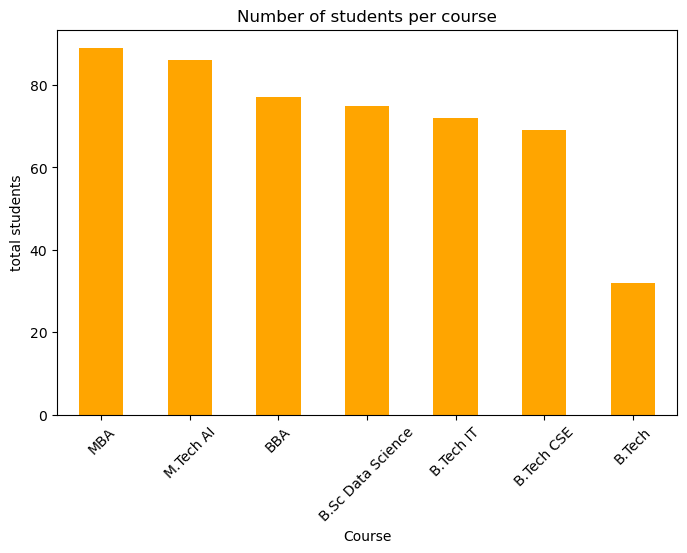

In [7]:
# EDA Visualization for students per course
plt.figure(figsize=(8,5))
course_count.plot(kind='bar',color='orange')
plt.title("Number of students per course")
plt.xlabel("Course")
plt.ylabel("total students")
plt.xticks(rotation=45)
plt.show()
# result: number of students per course is higher in MBA and lowest in B.Tech

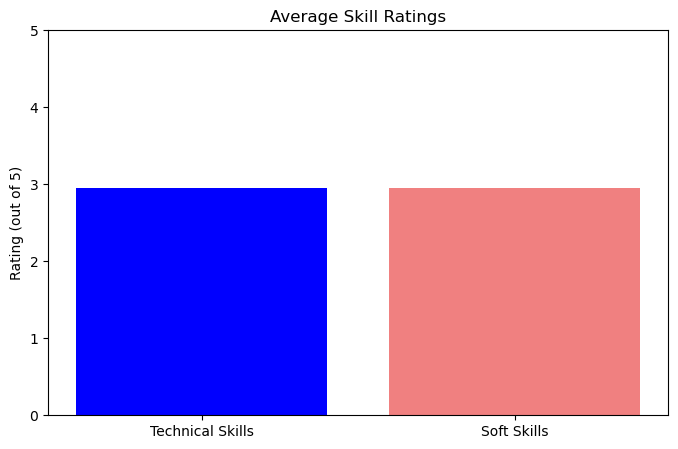

In [8]:
# analysis on average skill ratings
plt.figure(figsize=(8,5))
avg_ratings=[df["rating"].mean(),df["rating.1"].mean()]
labels=["Technical Skills","Soft Skills"]
plt.bar(labels,avg_ratings,color=['blue','lightcoral'])
plt.title("Average Skill Ratings")
plt.ylabel("Rating (out of 5)")
plt.ylim(0,5)
plt.show()
# Result: Both soft and technical skills are equal i.e(3 out of 5)

In [9]:
# analyzing top students
top_students=df.sort_values(by="rating",ascending=False).head(5)
print("Top five students by tech rating:")
print(top_students[["name","rating","rating.1","projects"]])
#using cutoff values out of 3
technical_threshold = 3
soft_threshold = 3


Top five students by tech rating:
              name  rating  rating.1 projects
492   Sanjana Nair       5         4      Yes
273   Ananya Patel       5         4       No
490       Neha Das       5         3      Yes
289    Arjun Patel       5         2       No
48   Sanjana Patel       5         1      Yes


RESULT               name  rating  rating.1  Overall_Skill_Gap
0  Shravani Khurpe       2         1  Skill Gap Present
1    Bhumika Yadav       3         4       Career Ready
2   Nandana Pramod       4         1  Skill Gap Present
3     Janvi Thakur       3         4       Career Ready
4    Atharva Joshi       4         3       Career Ready


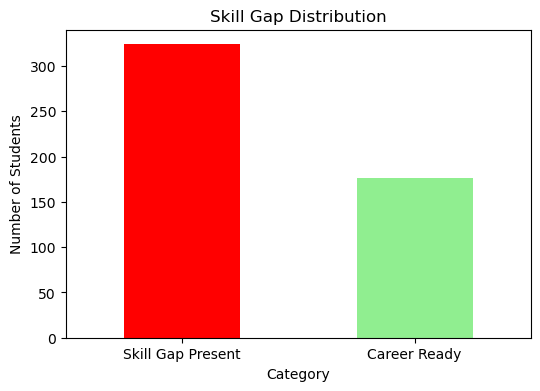

In [10]:
# Detecting gaps
# np.where(condition,value_if_true,value_if_false)
df["TechSkill_Gap"] = np.where(df["rating"] < technical_threshold, "Needs Improvement", "Good")
df["SoftSkill_Gap"] = np.where(df["rating.1"] < soft_threshold, "Needs Improvement", "Good")

# Combining both
df["Overall_Skill_Gap"] = np.where((df["rating"] < technical_threshold)|(df["rating.1"] < soft_threshold),"Skill Gap Present","Career Ready")
print("RESULT",df[["name","rating","rating.1","Overall_Skill_Gap"]].head(5))
plt.figure(figsize=(6,4))
df["Overall_Skill_Gap"].value_counts().plot(kind='bar', color=['red','lightgreen'])
plt.title("Skill Gap Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=360)
plt.show()

In [11]:
# calculating career readiness score
df["Career_Readiness_Score"]=(df["rating"]+df["rating.1"])/2
print(df[["name","rating","rating.1","Career_Readiness_Score","Overall_Skill_Gap"]].head())

              name  rating  rating.1  Career_Readiness_Score  \
0  Shravani Khurpe       2         1                     1.5   
1    Bhumika Yadav       3         4                     3.5   
2   Nandana Pramod       4         1                     2.5   
3     Janvi Thakur       3         4                     3.5   
4    Atharva Joshi       4         3                     3.5   

   Overall_Skill_Gap  
0  Skill Gap Present  
1       Career Ready  
2  Skill Gap Present  
3       Career Ready  
4       Career Ready  


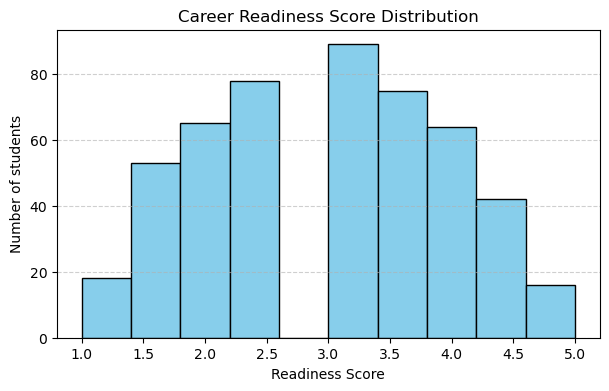

In [12]:
# visualizing readiness distributiom
plt.figure(figsize=(7,4))
plt.hist(df["Career_Readiness_Score"],bins=10,color="skyblue",edgecolor="black")
plt.title("Career Readiness Score Distribution")
plt.xlabel("Readiness Score")
plt.ylabel("Number of students")
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()
# result:scores near 5 is considered to be excellent and ready for career
# scores near 2-3 needs improvement

In [13]:
# prediction model
# creating career status label
df["Career_Readiness_Score"]=(df["rating"]+df["rating.1"])/2
readiness_threshold=4
df["Career_Status"]=np.where(df["Career_Readiness_Score"]>=readiness_threshold,1,0)
# 0=needs improvement,1=career ready

# selecting features and label
X=df[["rating","rating.1"]]
y=df["Career_Status"]

# splitting the dataset into train/test data
# splits the data into 70% for training(learning) and 30% for testing (accuracy check)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
# training logistic regression model
model =LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\n Classification Report:\n",classification_report(y_test,y_pred))

Accuracy: 1.0

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       112
           1       1.00      1.00      1.00        38

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [14]:
# confusion matrix
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:\n",cm)


Confusion Matrix:
 [[112   0]
 [  0  38]]


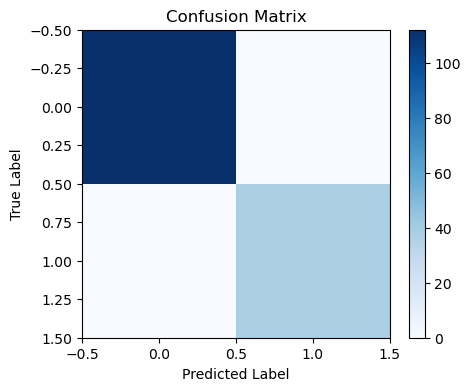

In [15]:
# visualizing the confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm,cmap='Blues',interpolation='nearest')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.show()
# model predicted 0 correctly 112 times and 1 correctly 38 times
# darkest cell is TN-112(True negative) and TP-38(True Positive),white squares means 0 errors
#higher the number of correct predictions darker the color


In [16]:
# prediction for a new student
# example
new_student = pd.DataFrame([[2,4]],columns=['rating','rating.1']) 
prediction=model.predict(new_student)
if prediction ==1:
    print("This student is Career Ready.")
else:
    print("This student Needs Improvement.")

This student Needs Improvement.
